# Computational Probability & Statistics

This notebook implements the computational demonstrations for the probability and statistics
foundation module. Every topic from [theory.md](theory.md) is exercised here through
simulation, visualization, and numerical verification.

**Contents:**

1. Distribution Gallery — PMF/PDF for all six core distributions
2. Bayes' Theorem Calculator — medical testing, base-rate fallacy
3. Conditional Probability — dice/card simulations
4. Monte Carlo $\pi$ Estimation — convergence analysis
5. Law of Large Numbers — running average convergence
6. Central Limit Theorem — non-normal → normal emergence
7. Random Walk Simulation — 1D and 2D diffusive behavior
8. Markov Chain Simulation — weather model, stationary distribution
9. Maximum Likelihood Estimation — Normal and Exponential from scratch
10. Memoryless Property — exponential distribution verification

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.gridspec import GridSpec

# Reproducibility
rng = np.random.default_rng(42)

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

print('Environment ready.')

Environment ready.


---
## 1. Distribution Gallery

We plot the PMF or PDF for all six distributions from theory.md Section 4:
Bernoulli, Binomial, Poisson (discrete) and Uniform, Normal, Exponential (continuous).

For each distribution we show:
- The theoretical PMF/PDF curve
- Key parameters and moments ($E[X]$, $\operatorname{Var}(X)$)

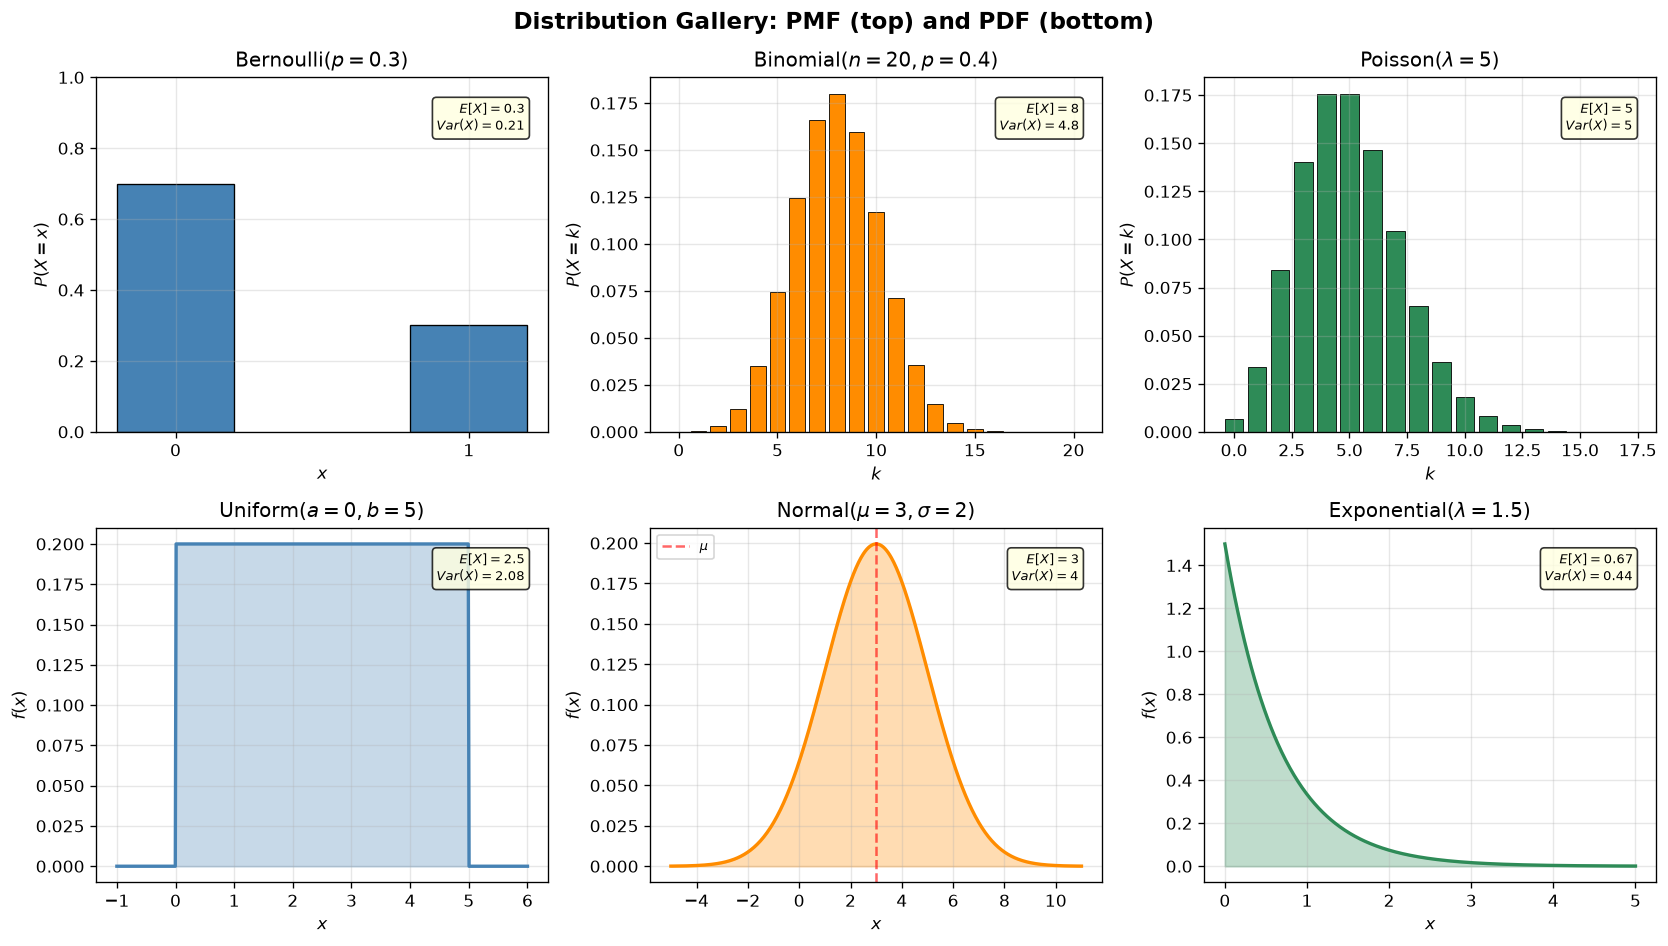

Distribution gallery plotted successfully.


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribution Gallery: PMF (top) and PDF (bottom)', fontsize=14, fontweight='bold')

# --- Row 1: Discrete distributions ---

# 1a. Bernoulli(p=0.3)
ax = axes[0, 0]
p = 0.3
x_bern = np.array([0, 1])
pmf_bern = np.array([1 - p, p])
ax.bar(x_bern, pmf_bern, color='steelblue', width=0.4, edgecolor='black', linewidth=0.8)
ax.set_title(f'Bernoulli($p={p}$)')
ax.set_xlabel('$x$')
ax.set_ylabel('$P(X=x)$')
ax.set_xticks([0, 1])
ax.set_ylim(0, 1)
ax.text(0.95, 0.85, f'$E[X]={p:.1f}$\n$Var(X)={p*(1-p):.2f}$',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 1b. Binomial(n=20, p=0.4)
ax = axes[0, 1]
n_binom, p_binom = 20, 0.4
k = np.arange(0, n_binom + 1)
pmf_binom = stats.binom.pmf(k, n_binom, p_binom)
ax.bar(k, pmf_binom, color='darkorange', edgecolor='black', linewidth=0.5)
ax.set_title(f'Binomial($n={n_binom}, p={p_binom}$)')
ax.set_xlabel('$k$')
ax.set_ylabel('$P(X=k)$')
ax.text(0.95, 0.85, f'$E[X]={n_binom*p_binom:.0f}$\n$Var(X)={n_binom*p_binom*(1-p_binom):.1f}$',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 1c. Poisson(lambda=5)
ax = axes[0, 2]
lam = 5
k_pois = np.arange(0, 18)
pmf_pois = stats.poisson.pmf(k_pois, lam)
ax.bar(k_pois, pmf_pois, color='seagreen', edgecolor='black', linewidth=0.5)
ax.set_title(f'Poisson($\\lambda={lam}$)')
ax.set_xlabel('$k$')
ax.set_ylabel('$P(X=k)$')
ax.text(0.95, 0.85, f'$E[X]={lam}$\n$Var(X)={lam}$',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Row 2: Continuous distributions ---

# 2a. Uniform(0, 5)
ax = axes[1, 0]
a_unif, b_unif = 0, 5
x_unif = np.linspace(-1, 6, 500)
pdf_unif = stats.uniform.pdf(x_unif, loc=a_unif, scale=b_unif - a_unif)
ax.fill_between(x_unif, pdf_unif, alpha=0.3, color='steelblue')
ax.plot(x_unif, pdf_unif, color='steelblue', linewidth=2)
ax.set_title(f'Uniform($a={a_unif}, b={b_unif}$)')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
mean_u = (a_unif + b_unif) / 2
var_u = (b_unif - a_unif)**2 / 12
ax.text(0.95, 0.85, f'$E[X]={mean_u:.1f}$\n$Var(X)={var_u:.2f}$',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 2b. Normal(mu=3, sigma^2=4)
ax = axes[1, 1]
mu_n, sigma_n = 3, 2
x_norm = np.linspace(mu_n - 4*sigma_n, mu_n + 4*sigma_n, 500)
pdf_norm = stats.norm.pdf(x_norm, mu_n, sigma_n)
ax.fill_between(x_norm, pdf_norm, alpha=0.3, color='darkorange')
ax.plot(x_norm, pdf_norm, color='darkorange', linewidth=2)
ax.axvline(mu_n, color='red', linestyle='--', alpha=0.6, label='$\\mu$')
ax.set_title(f'Normal($\\mu={mu_n}, \\sigma={sigma_n}$)')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.legend(fontsize=8)
ax.text(0.95, 0.85, f'$E[X]={mu_n}$\n$Var(X)={sigma_n**2}$',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 2c. Exponential(lambda=1.5)
ax = axes[1, 2]
lam_exp = 1.5
x_exp = np.linspace(0, 5, 500)
pdf_exp = stats.expon.pdf(x_exp, scale=1/lam_exp)
ax.fill_between(x_exp, pdf_exp, alpha=0.3, color='seagreen')
ax.plot(x_exp, pdf_exp, color='seagreen', linewidth=2)
ax.set_title(f'Exponential($\\lambda={lam_exp}$)')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.text(0.95, 0.85, f'$E[X]={1/lam_exp:.2f}$\n$Var(X)={1/lam_exp**2:.2f}$',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('distribution_gallery.png', dpi=150, bbox_inches='tight')
plt.show()
print('Distribution gallery plotted successfully.')

---
## 2. Bayes' Theorem Calculator — Medical Testing

From theory.md Section 2.5: A disease has prevalence $P(\text{disease}) = 0.01$, the test has
sensitivity $P(+|\text{disease}) = 0.95$ and specificity $P(-|\text{no disease}) = 0.90$.

We compute $P(\text{disease}|+)$ via Bayes' theorem and visualize how the posterior changes
with prevalence to expose the **base rate fallacy**.

Medical Test Bayes' Theorem Calculation
Prevalence P(disease)     = 1.00%
Sensitivity P(+|disease)  = 95.00%
Specificity P(-|healthy)  = 90.00%

P(disease | positive)     = 0.0876 (8.8%)

Despite a 95% sensitive test, only 8.8% of positive results are true positives!
This is the base rate fallacy.


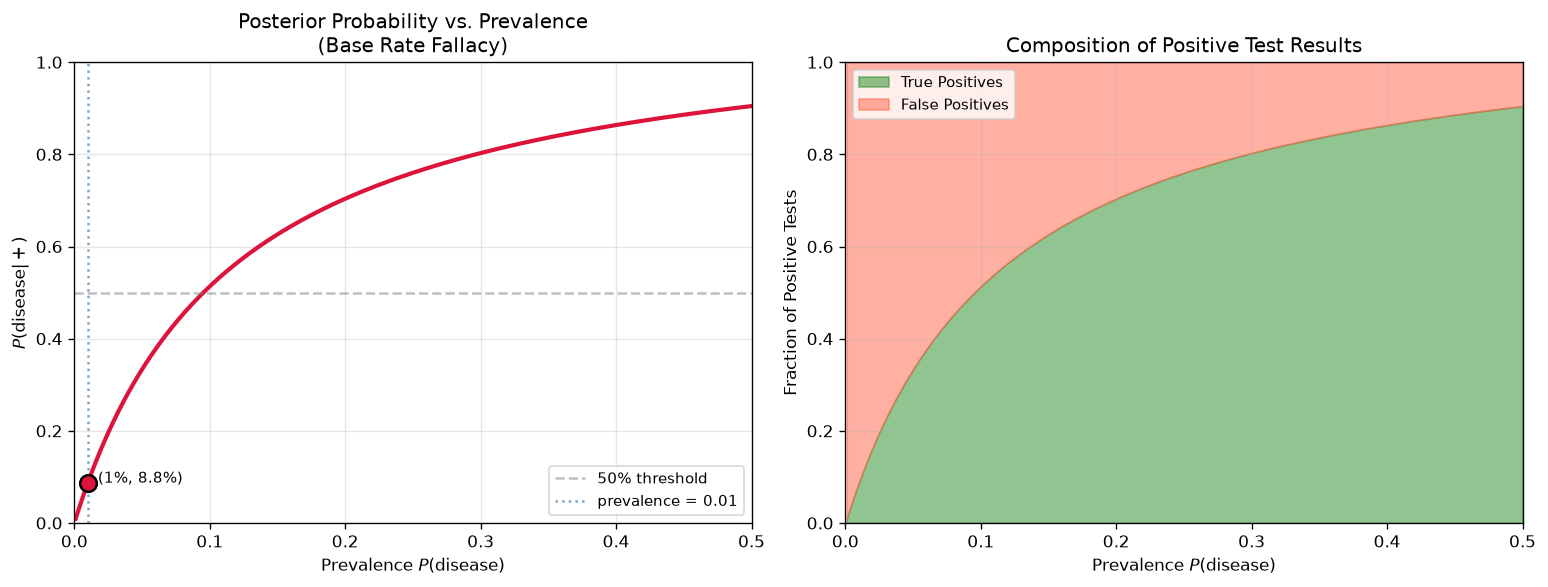

In [3]:
def bayes_medical(prevalence, sensitivity, specificity):
    # Compute P(disease | positive test) using Bayes' theorem.
    # prevalence:  P(disease) -- prior probability
    # sensitivity: P(positive | disease) -- true positive rate
    # specificity: P(negative | no disease) -- true negative rate
    # Returns:     P(disease | positive test)
    false_pos_rate = 1 - specificity
    p_pos = sensitivity * prevalence + false_pos_rate * (1 - prevalence)
    posterior = (sensitivity * prevalence) / p_pos
    return posterior

# Parameters from theory.md
sensitivity = 0.95
specificity = 0.90
prevalence = 0.01

posterior = bayes_medical(prevalence, sensitivity, specificity)
print(f"Medical Test Bayes' Theorem Calculation")
print(f"{'=' * 45}")
print(f"Prevalence P(disease)     = {prevalence:.2%}")
print(f"Sensitivity P(+|disease)  = {sensitivity:.2%}")
print(f"Specificity P(-|healthy)  = {specificity:.2%}")
print()
print(f"P(disease | positive)     = {posterior:.4f} ({posterior:.1%})")
print(f"\nDespite a 95% sensitive test, only {posterior:.1%} of positive results are true positives!")
print(f"This is the base rate fallacy.")

# --- Visualization: posterior vs prevalence ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: posterior vs prevalence
prevalences = np.linspace(0.001, 0.5, 500)
posteriors = [bayes_medical(p, sensitivity, specificity) for p in prevalences]

ax1.plot(prevalences, posteriors, color='crimson', linewidth=2.5)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax1.axvline(x=prevalence, color='steelblue', linestyle=':', alpha=0.7, label=f'prevalence = {prevalence}')
ax1.scatter([prevalence], [posterior], color='crimson', s=100, zorder=5,
            edgecolors='black', linewidths=1.5)
ax1.annotate(f'  ({prevalence:.0%}, {posterior:.1%})',
             xy=(prevalence, posterior), fontsize=9)
ax1.set_xlabel('Prevalence $P(\\text{disease})$')
ax1.set_ylabel('$P(\\text{disease} | +)$')
ax1.set_title('Posterior Probability vs. Prevalence\n(Base Rate Fallacy)')
ax1.legend(fontsize=9)
ax1.set_xlim(0, 0.5)
ax1.set_ylim(0, 1)

# Right: breakdown of positive test results (stacked area)
tp = sensitivity * prevalences           # true positives
fp = (1 - specificity) * (1 - prevalences)  # false positives
ax2.fill_between(prevalences, 0, tp / (tp + fp), alpha=0.5, color='forestgreen', label='True Positives')
ax2.fill_between(prevalences, tp / (tp + fp), 1, alpha=0.5, color='tomato', label='False Positives')
ax2.set_xlabel('Prevalence $P(\\text{disease})$')
ax2.set_ylabel('Fraction of Positive Tests')
ax2.set_title('Composition of Positive Test Results')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 0.5)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('bayes_base_rate.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Conditional Probability — Simulation Verification

We verify conditional probability formulas from theory.md Section 2.1 using Monte Carlo
simulation.

**Example 1 (Dice):** Roll a fair die. Given the result is even, what is $P(X=6)$?

$$P(X=6 \mid \text{even}) = \frac{P(\{6\})}{P(\{2,4,6\})} = \frac{1/6}{3/6} = \frac{1}{3}$$

**Example 2 (Cards):** Draw a card from a standard 52-card deck. Given the card is a face card
(J, Q, K), what is $P(\text{heart})$?

$$P(\text{heart} \mid \text{face card}) = \frac{3}{12} = \frac{1}{4}$$

Example 1: P(X=6 | even) for a fair die
  Exact:     0.333333
  Simulated: 0.333215  (n=500,000)
  Error:     0.000119

Example 2: P(heart | face card) for a standard deck
  Exact:     0.250000
  Simulated: 0.251027  (n=500,000)
  Error:     0.001027



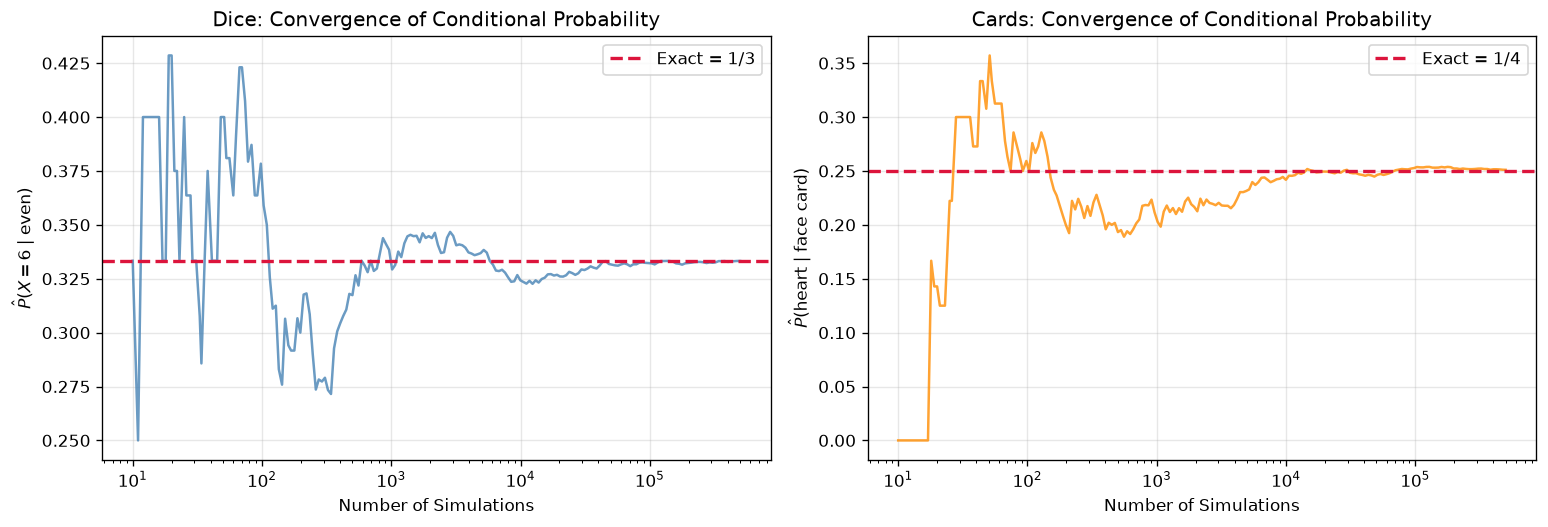

In [4]:
n_sim = 500_000

# --- Example 1: Dice conditional probability ---
rolls = rng.integers(1, 7, size=n_sim)  # fair die rolls {1,2,3,4,5,6}
even_mask = (rolls % 2 == 0)
p_6_given_even_sim = np.mean(rolls[even_mask] == 6)
p_6_given_even_exact = 1/3

print('Example 1: P(X=6 | even) for a fair die')
print(f'  Exact:     {p_6_given_even_exact:.6f}')
print(f'  Simulated: {p_6_given_even_sim:.6f}  (n={n_sim:,})')
print(f'  Error:     {abs(p_6_given_even_sim - p_6_given_even_exact):.6f}')
print()

# --- Example 2: Card conditional probability ---
# Encode a 52-card deck: suits 0-3 (heart=0), ranks 0-12 (J=10, Q=11, K=12)
draws = rng.integers(0, 52, size=n_sim)
suits = draws // 13       # 0=hearts, 1=diamonds, 2=clubs, 3=spades
ranks = draws % 13        # 0=Ace, ..., 9=10, 10=J, 11=Q, 12=K

face_mask = ranks >= 10   # J, Q, K
heart_mask = suits == 0

p_heart_given_face_sim = np.mean(heart_mask[face_mask])
p_heart_given_face_exact = 3/12

print('Example 2: P(heart | face card) for a standard deck')
print(f'  Exact:     {p_heart_given_face_exact:.6f}')
print(f'  Simulated: {p_heart_given_face_sim:.6f}  (n={n_sim:,})')
print(f'  Error:     {abs(p_heart_given_face_sim - p_heart_given_face_exact):.6f}')
print()

# --- Convergence plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Dice convergence
ns = np.logspace(1, np.log10(n_sim), 200).astype(int)
dice_conv = [np.mean(rolls[:n][rolls[:n] % 2 == 0] == 6) if np.any(rolls[:n] % 2 == 0) else 0
             for n in ns]
ax1.semilogx(ns, dice_conv, color='steelblue', linewidth=1.5, alpha=0.8)
ax1.axhline(y=1/3, color='crimson', linestyle='--', linewidth=2, label='Exact = 1/3')
ax1.set_xlabel('Number of Simulations')
ax1.set_ylabel('$\\hat{P}(X=6 \\mid \\text{even})$')
ax1.set_title('Dice: Convergence of Conditional Probability')
ax1.legend()

# Card convergence
card_conv = [np.mean(heart_mask[:n][face_mask[:n]]) if np.any(face_mask[:n]) else 0
             for n in ns]
ax2.semilogx(ns, card_conv, color='darkorange', linewidth=1.5, alpha=0.8)
ax2.axhline(y=0.25, color='crimson', linestyle='--', linewidth=2, label='Exact = 1/4')
ax2.set_xlabel('Number of Simulations')
ax2.set_ylabel('$\\hat{P}(\\text{heart} \\mid \\text{face card})$')
ax2.set_title('Cards: Convergence of Conditional Probability')
ax2.legend()

plt.tight_layout()
plt.savefig('conditional_probability.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Monte Carlo $\pi$ Estimation

From theory.md Section 7.2: sample points uniformly in $[0,1]^2$ and count the fraction
inside the quarter circle $x^2 + y^2 \le 1$. This fraction approximates $\pi/4$.

By the CLT, the error scales as $O(1/\sqrt{n})$. We verify this convergence rate.

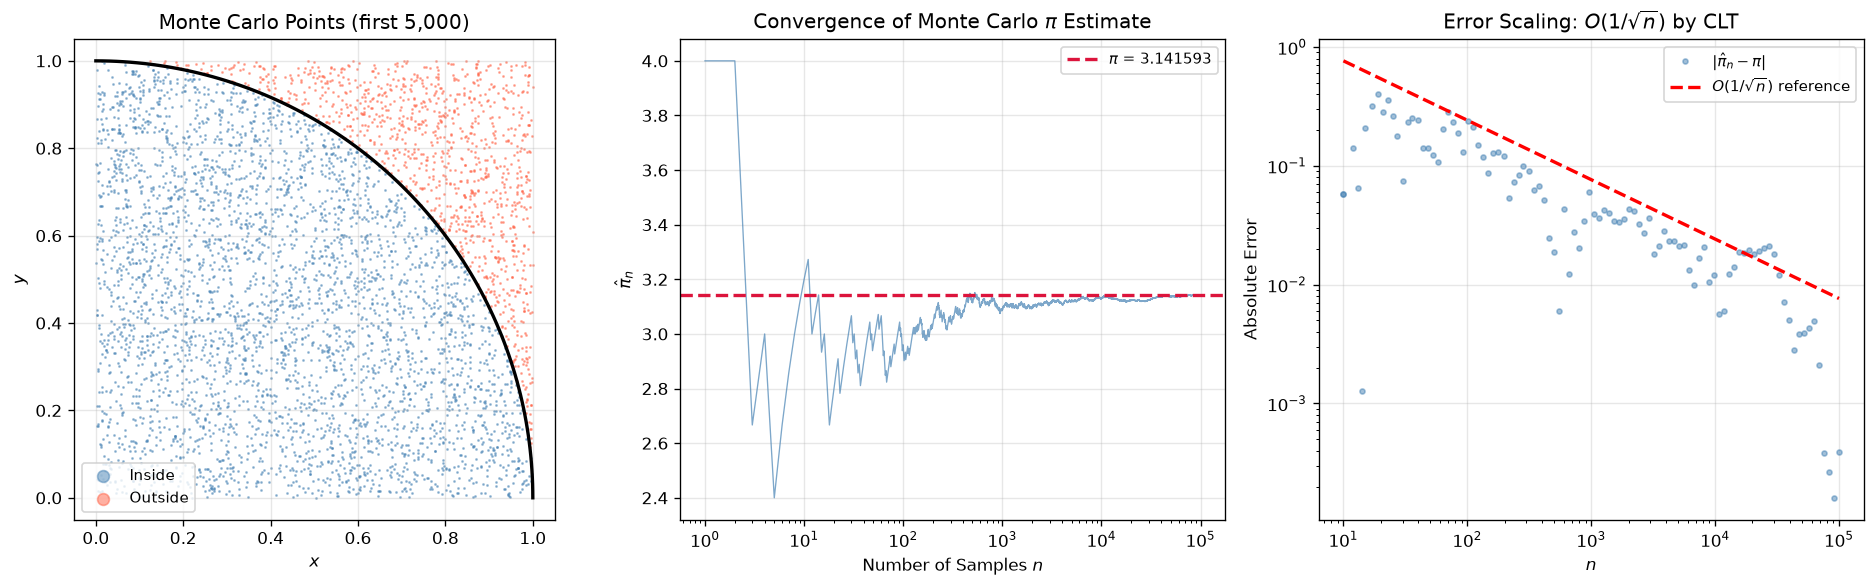

Final estimate: pi = 3.141200
True value:     pi = 3.141593
Error:          0.000393


In [5]:
n_total = 100_000

x = rng.uniform(0, 1, n_total)
y = rng.uniform(0, 1, n_total)
inside = (x**2 + y**2) <= 1.0

# Running estimate of pi
cumulative_inside = np.cumsum(inside)
n_range = np.arange(1, n_total + 1)
pi_estimates = 4.0 * cumulative_inside / n_range

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: scatter plot of points
ax = axes[0]
n_show = 5000
ax.scatter(x[:n_show][inside[:n_show]], y[:n_show][inside[:n_show]],
           s=0.5, alpha=0.5, color='steelblue', label='Inside')
ax.scatter(x[:n_show][~inside[:n_show]], y[:n_show][~inside[:n_show]],
           s=0.5, alpha=0.5, color='tomato', label='Outside')
theta = np.linspace(0, np.pi/2, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)
ax.set_aspect('equal')
ax.set_title(f'Monte Carlo Points (first {n_show:,})')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.legend(markerscale=10, fontsize=9)

# Middle: convergence of pi estimate
ax = axes[1]
ax.semilogx(n_range, pi_estimates, color='steelblue', linewidth=0.8, alpha=0.7)
ax.axhline(y=np.pi, color='crimson', linestyle='--', linewidth=2, label=f'$\\pi$ = {np.pi:.6f}')
ax.set_xlabel('Number of Samples $n$')
ax.set_ylabel('$\\hat{\\pi}_n$')
ax.set_title('Convergence of Monte Carlo $\\pi$ Estimate')
ax.legend(fontsize=9)

# Right: error vs n (log-log) with 1/sqrt(n) reference
ax = axes[2]
sample_sizes = np.logspace(1, np.log10(n_total), 100).astype(int)
errors = np.abs(pi_estimates[sample_sizes - 1] - np.pi)
ax.loglog(sample_sizes, errors, 'o', markersize=3, alpha=0.5, color='steelblue', label='$|\\hat{\\pi}_n - \\pi|$')
# Reference line: C / sqrt(n)
c_ref = errors[len(errors)//4] * np.sqrt(sample_sizes[len(errors)//4])
ax.loglog(sample_sizes, c_ref / np.sqrt(sample_sizes), 'r--', linewidth=2,
          label='$O(1/\\sqrt{n})$ reference')
ax.set_xlabel('$n$')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Scaling: $O(1/\\sqrt{n})$ by CLT')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('monte_carlo_pi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Final estimate: pi = {pi_estimates[-1]:.6f}')
print(f'True value:     pi = {np.pi:.6f}')
print(f'Error:          {abs(pi_estimates[-1] - np.pi):.6f}')

---
## 5. Law of Large Numbers Demo

From theory.md Section 5.5: The sample mean $\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$
converges to $E[X]$ as $n \to \infty$.

We simulate die rolls ($E[X] = 3.5$) and show the running average converging to 3.5.
Multiple independent sequences are shown to illustrate the universality of convergence.

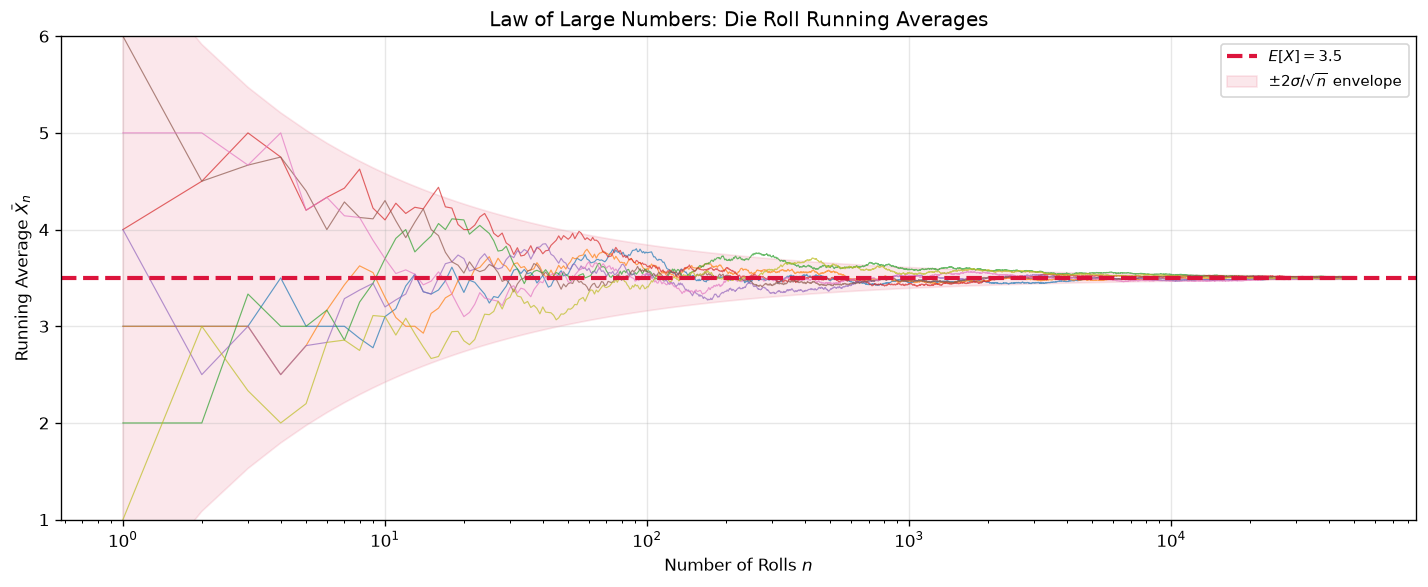

Final running averages for each sequence:
  Sequence 1: 3.4894
  Sequence 2: 3.5013
  Sequence 3: 3.4987
  Sequence 4: 3.5008
  Sequence 5: 3.5119
  Sequence 6: 3.5137
  Sequence 7: 3.4796
  Sequence 8: 3.5035
  True E[X]: 3.5000


In [6]:
n_rolls = 50_000
n_sequences = 8

fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.tab10(np.linspace(0, 0.8, n_sequences))
for i in range(n_sequences):
    rolls = rng.integers(1, 7, size=n_rolls)
    running_avg = np.cumsum(rolls) / np.arange(1, n_rolls + 1)
    ax.semilogx(range(1, n_rolls + 1), running_avg, linewidth=0.7,
                alpha=0.7, color=colors[i])

ax.axhline(y=3.5, color='crimson', linestyle='--', linewidth=2.5, label='$E[X] = 3.5$')
ax.set_xlabel('Number of Rolls $n$')
ax.set_ylabel('Running Average $\\bar{X}_n$')
ax.set_title('Law of Large Numbers: Die Roll Running Averages')
ax.set_ylim(1, 6)

# Add shaded band for +/- 2*sigma/sqrt(n) envelope
n_arr = np.arange(1, n_rolls + 1)
sigma_die = np.sqrt(35/12)  # Var(die) = 35/12
envelope = 2 * sigma_die / np.sqrt(n_arr)  # ~95% band
ax.fill_between(n_arr, 3.5 - envelope, 3.5 + envelope, alpha=0.1, color='crimson',
                label='$\\pm 2\\sigma/\\sqrt{n}$ envelope')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('lln_demo.png', dpi=150, bbox_inches='tight')
plt.show()

# Verification: final averages
print('Final running averages for each sequence:')
for i in range(n_sequences):
    rolls = rng.integers(1, 7, size=n_rolls)
    final_avg = np.mean(rolls)
    print(f'  Sequence {i+1}: {final_avg:.4f}')
print(f'  True E[X]: 3.5000')

---
## 6. Central Limit Theorem Demo

From theory.md Section 5.6: The standardized sample mean
$\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} \mathcal{N}(0,1)$.

We demonstrate this using **three non-normal distributions**:
- Exponential($\lambda=1$): heavily right-skewed
- Uniform(0,1): flat
- Bernoulli($p=0.3$): discrete, asymmetric

For each, we show histograms of the sample mean for increasing sample sizes $n$,
overlaid with the theoretical normal density.

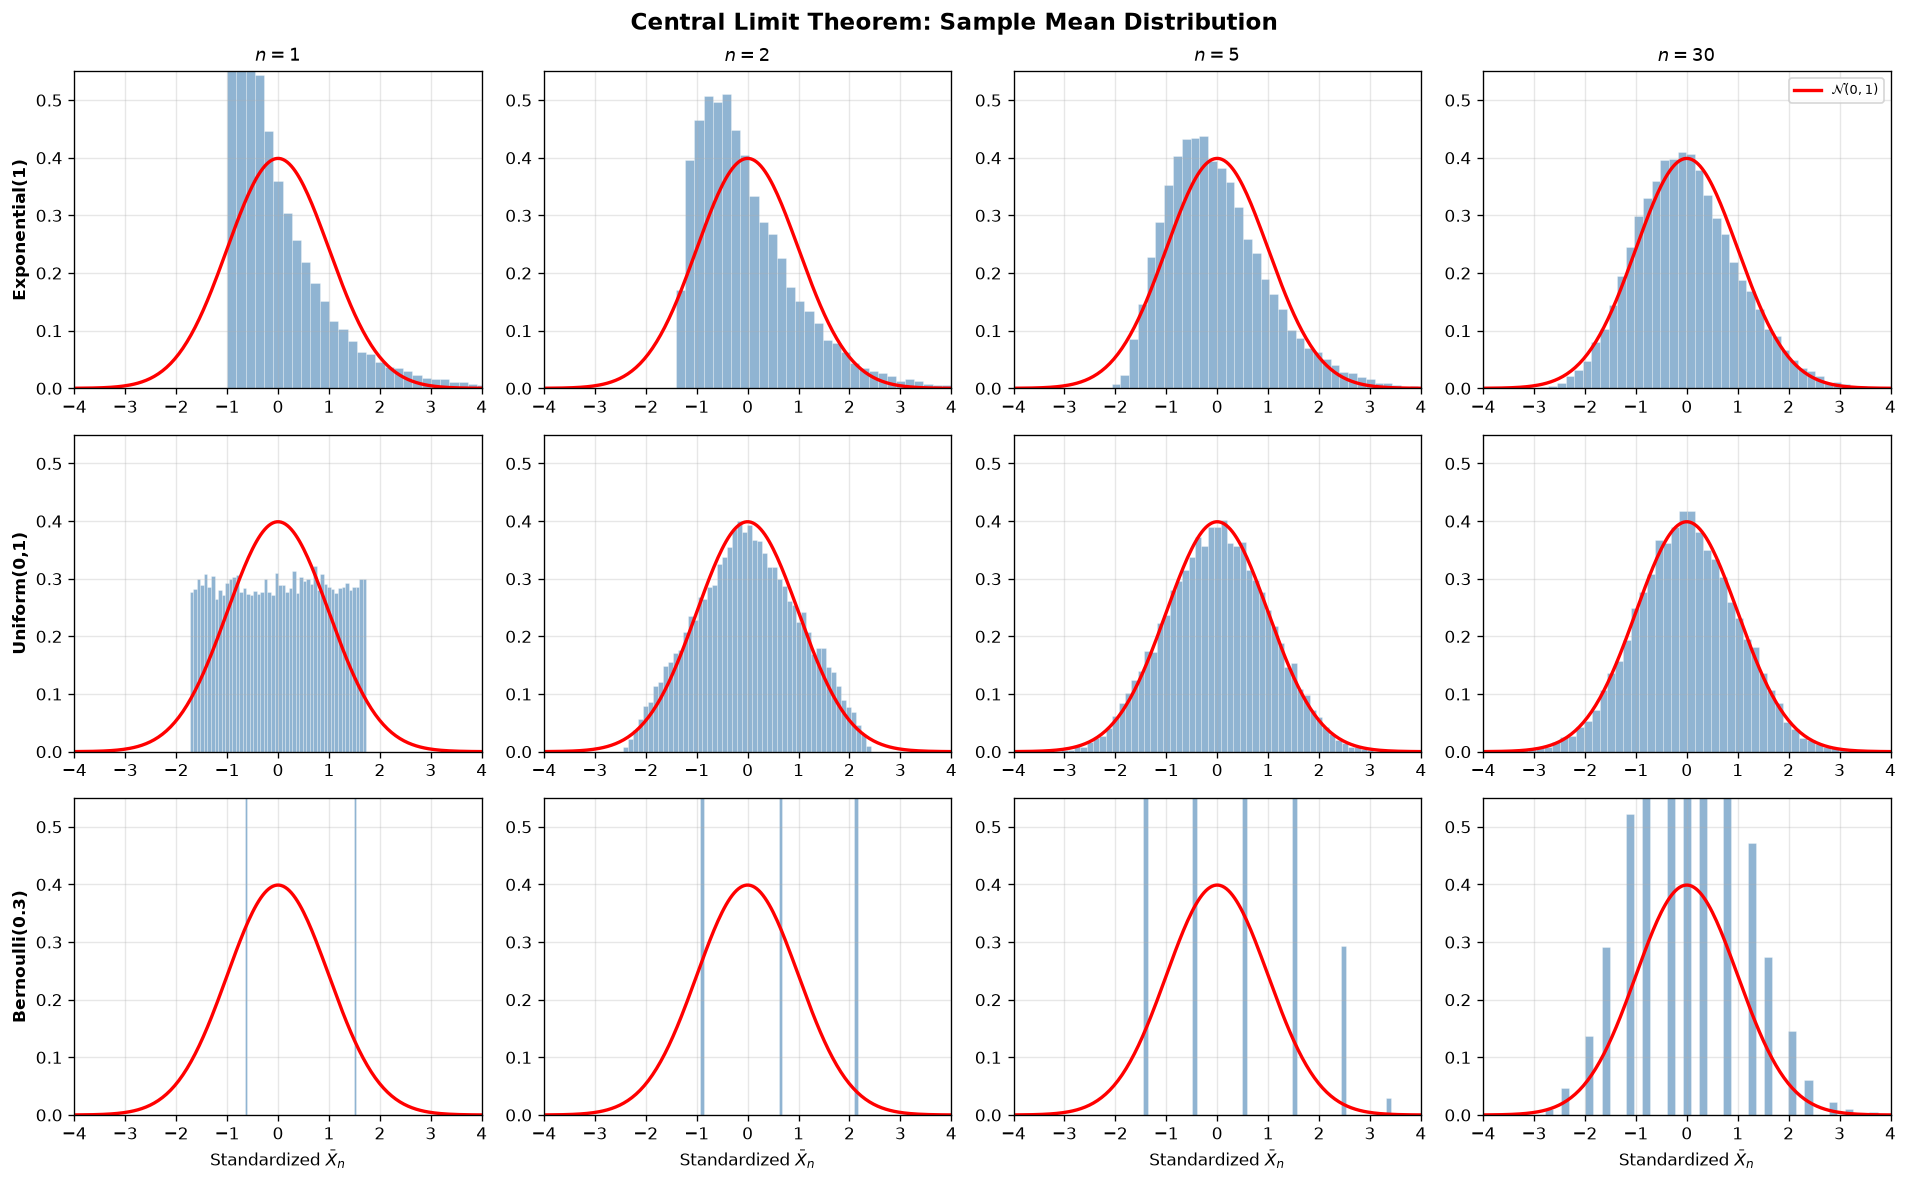

CLT demonstration: as n increases, all three distributions converge to N(0,1).


In [7]:
distributions = {
    'Exponential(1)': {'sampler': lambda size: rng.exponential(1.0, size), 'mu': 1.0, 'sigma': 1.0},
    'Uniform(0,1)':   {'sampler': lambda size: rng.uniform(0, 1, size),   'mu': 0.5, 'sigma': np.sqrt(1/12)},
    'Bernoulli(0.3)': {'sampler': lambda size: rng.binomial(1, 0.3, size),'mu': 0.3, 'sigma': np.sqrt(0.3*0.7)},
}

sample_sizes = [1, 2, 5, 30]
n_reps = 20_000

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Central Limit Theorem: Sample Mean Distribution', fontsize=14, fontweight='bold')

for row, (dist_name, params) in enumerate(distributions.items()):
    sampler = params['sampler']
    mu = params['mu']
    sigma = params['sigma']

    for col, n in enumerate(sample_sizes):
        ax = axes[row, col]

        # Generate n_reps sample means, each from n observations
        sample_means = np.array([sampler(n).mean() for _ in range(n_reps)])

        # Standardize
        std_means = (sample_means - mu) / (sigma / np.sqrt(n))

        ax.hist(std_means, bins=50, density=True, alpha=0.6, color='steelblue',
                edgecolor='white', linewidth=0.3)

        # Overlay N(0,1) PDF
        z = np.linspace(-4, 4, 200)
        ax.plot(z, stats.norm.pdf(z), 'r-', linewidth=2, label='$\\mathcal{N}(0,1)$')

        if col == 0:
            ax.set_ylabel(dist_name, fontsize=10, fontweight='bold')
        if row == 0:
            ax.set_title(f'$n = {n}$', fontsize=11)
        if row == 2:
            ax.set_xlabel('Standardized $\\bar{X}_n$')

        ax.set_xlim(-4, 4)
        ax.set_ylim(0, 0.55)

        if row == 0 and col == 3:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('clt_demo.png', dpi=150, bbox_inches='tight')
plt.show()

print('CLT demonstration: as n increases, all three distributions converge to N(0,1).')

---
## 7. Random Walk Simulation

A random walk demonstrates diffusive behavior. At each step, the walker moves $\pm 1$
with equal probability.

**Key result:** After $n$ steps, the expected displacement is 0 but the root-mean-square
displacement grows as $\sqrt{n}$:

$$E[X_n] = 0, \quad E[X_n^2] = n, \quad \text{RMS displacement} = \sqrt{n}$$

We simulate both **1D** and **2D** random walks and verify the $\sqrt{n}$ scaling.

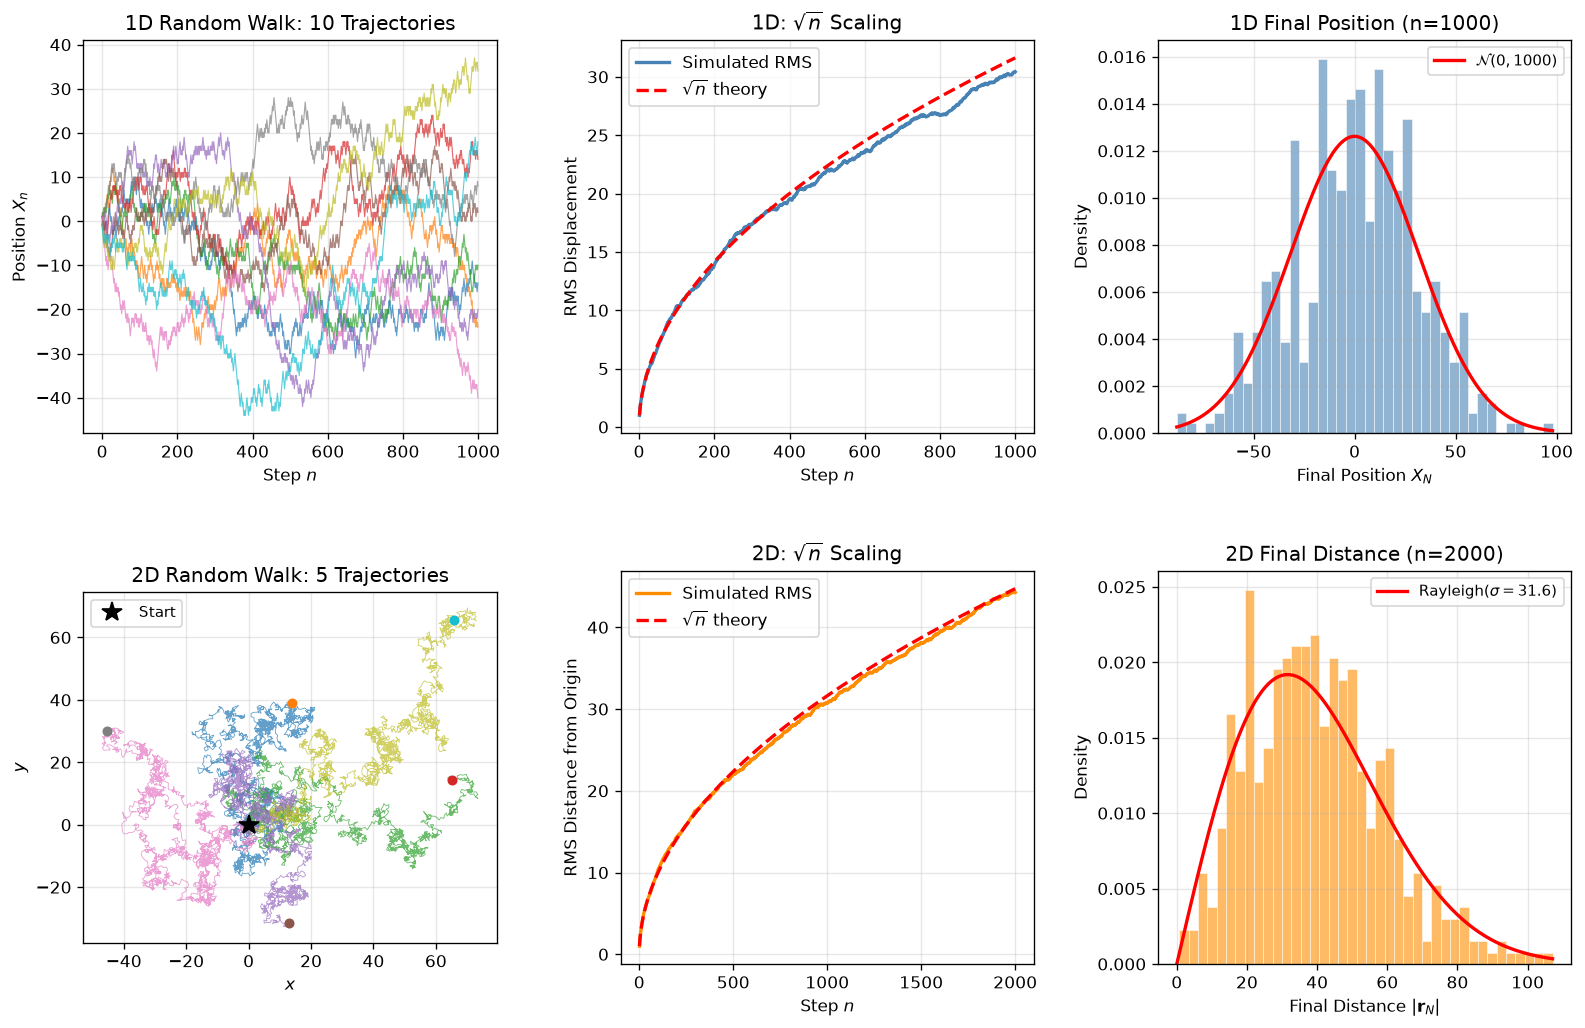

1D RMS at n=1000: simulated=30.43, theory=31.62
2D RMS at n=2000: simulated=44.26, theory=44.72


In [8]:
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# --- 1D Random Walk ---
n_steps_1d = 1000
n_walkers_1d = 500

# Panel 1: Sample 1D trajectories
ax1 = fig.add_subplot(gs[0, 0])
for i in range(10):
    steps = rng.choice([-1, 1], size=n_steps_1d)
    positions = np.cumsum(steps)
    ax1.plot(positions, linewidth=0.7, alpha=0.7)
ax1.set_xlabel('Step $n$')
ax1.set_ylabel('Position $X_n$')
ax1.set_title('1D Random Walk: 10 Trajectories')

# Panel 2: RMS displacement vs sqrt(n) for 1D
ax2 = fig.add_subplot(gs[0, 1])
all_walks_1d = np.cumsum(rng.choice([-1, 1], size=(n_walkers_1d, n_steps_1d)), axis=1)
rms_1d = np.sqrt(np.mean(all_walks_1d**2, axis=0))
n_arr = np.arange(1, n_steps_1d + 1)
ax2.plot(n_arr, rms_1d, color='steelblue', linewidth=2, label='Simulated RMS')
ax2.plot(n_arr, np.sqrt(n_arr), 'r--', linewidth=2, label='$\\sqrt{n}$ theory')
ax2.set_xlabel('Step $n$')
ax2.set_ylabel('RMS Displacement')
ax2.set_title('1D: $\\sqrt{n}$ Scaling')
ax2.legend()

# Panel 3: Distribution of final positions (1D)
ax3 = fig.add_subplot(gs[0, 2])
final_pos_1d = all_walks_1d[:, -1]
ax3.hist(final_pos_1d, bins=40, density=True, alpha=0.6, color='steelblue',
         edgecolor='white', linewidth=0.5)
x_fit = np.linspace(final_pos_1d.min(), final_pos_1d.max(), 200)
ax3.plot(x_fit, stats.norm.pdf(x_fit, 0, np.sqrt(n_steps_1d)), 'r-', linewidth=2,
         label=f'$\\mathcal{{N}}(0, {n_steps_1d})$')
ax3.set_xlabel('Final Position $X_N$')
ax3.set_ylabel('Density')
ax3.set_title(f'1D Final Position (n={n_steps_1d})')
ax3.legend(fontsize=9)

# --- 2D Random Walk ---
n_steps_2d = 2000

# Panel 4: Sample 2D trajectories
ax4 = fig.add_subplot(gs[1, 0])
for i in range(5):
    angles = rng.uniform(0, 2*np.pi, n_steps_2d)
    dx = np.cos(angles)
    dy = np.sin(angles)
    x_pos = np.cumsum(dx)
    y_pos = np.cumsum(dy)
    ax4.plot(x_pos, y_pos, linewidth=0.5, alpha=0.7)
    ax4.plot(x_pos[-1], y_pos[-1], 'o', markersize=5)
ax4.plot(0, 0, 'k*', markersize=12, label='Start')
ax4.set_xlabel('$x$')
ax4.set_ylabel('$y$')
ax4.set_title('2D Random Walk: 5 Trajectories')
ax4.set_aspect('equal')
ax4.legend(fontsize=9)

# Panel 5: RMS displacement vs sqrt(n) for 2D
ax5 = fig.add_subplot(gs[1, 1])
n_walkers_2d = 500
angles_all = rng.uniform(0, 2*np.pi, (n_walkers_2d, n_steps_2d))
x_all = np.cumsum(np.cos(angles_all), axis=1)
y_all = np.cumsum(np.sin(angles_all), axis=1)
r2_all = x_all**2 + y_all**2
rms_2d = np.sqrt(np.mean(r2_all, axis=0))
n_arr_2d = np.arange(1, n_steps_2d + 1)
ax5.plot(n_arr_2d, rms_2d, color='darkorange', linewidth=2, label='Simulated RMS')
ax5.plot(n_arr_2d, np.sqrt(n_arr_2d), 'r--', linewidth=2, label='$\\sqrt{n}$ theory')
ax5.set_xlabel('Step $n$')
ax5.set_ylabel('RMS Distance from Origin')
ax5.set_title('2D: $\\sqrt{n}$ Scaling')
ax5.legend()

# Panel 6: Distribution of final distances (2D)
ax6 = fig.add_subplot(gs[1, 2])
final_r = np.sqrt(x_all[:, -1]**2 + y_all[:, -1]**2)
ax6.hist(final_r, bins=40, density=True, alpha=0.6, color='darkorange',
         edgecolor='white', linewidth=0.5)
r_fit = np.linspace(0, final_r.max(), 200)
# Rayleigh distribution for 2D random walk
sigma_2d = np.sqrt(n_steps_2d / 2)
ax6.plot(r_fit, stats.rayleigh.pdf(r_fit, scale=sigma_2d), 'r-', linewidth=2,
         label=f'Rayleigh($\\sigma={sigma_2d:.1f}$)')
ax6.set_xlabel('Final Distance $|\\mathbf{r}_N|$')
ax6.set_ylabel('Density')
ax6.set_title(f'2D Final Distance (n={n_steps_2d})')
ax6.legend(fontsize=9)

plt.savefig('random_walks.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'1D RMS at n={n_steps_1d}: simulated={rms_1d[-1]:.2f}, theory={np.sqrt(n_steps_1d):.2f}')
print(f'2D RMS at n={n_steps_2d}: simulated={rms_2d[-1]:.2f}, theory={np.sqrt(n_steps_2d):.2f}')

---
## 8. Markov Chain Simulation — Weather Model

From theory.md Section 6.6: Two-state weather model (Sunny/Rainy) with transition matrix:

$$\mathbf{P} = \begin{pmatrix} 0.8 & 0.2 \\\\ 0.4 & 0.6 \end{pmatrix}$$

Stationary distribution: $\boldsymbol{\pi} = (2/3, 1/3)$.

We:
1. Simulate the chain and show the running fraction of sunny days converging to $2/3$
2. Compute $\mathbf{P}^k$ for increasing $k$ to show convergence
3. Verify the stationary distribution via eigenvalue decomposition: $\boldsymbol{\pi}$
   is the left eigenvector of $\mathbf{P}$ corresponding to eigenvalue 1

Markov Chain -- Eigenvalue Verification
Transition matrix P:
[[0.8 0.2]
 [0.4 0.6]]

Eigenvalues of P: [1.  0.4]
Stationary distribution (from eigenvector): [0.66666667 0.33333333]
Stationary distribution (exact):            [2/3, 1/3] = [0.666667, 0.333333]
Verification: pi @ P = [0.66666667 0.33333333]
Match: True
Stationary distribution (simulation):       [0.65935 0.34065]


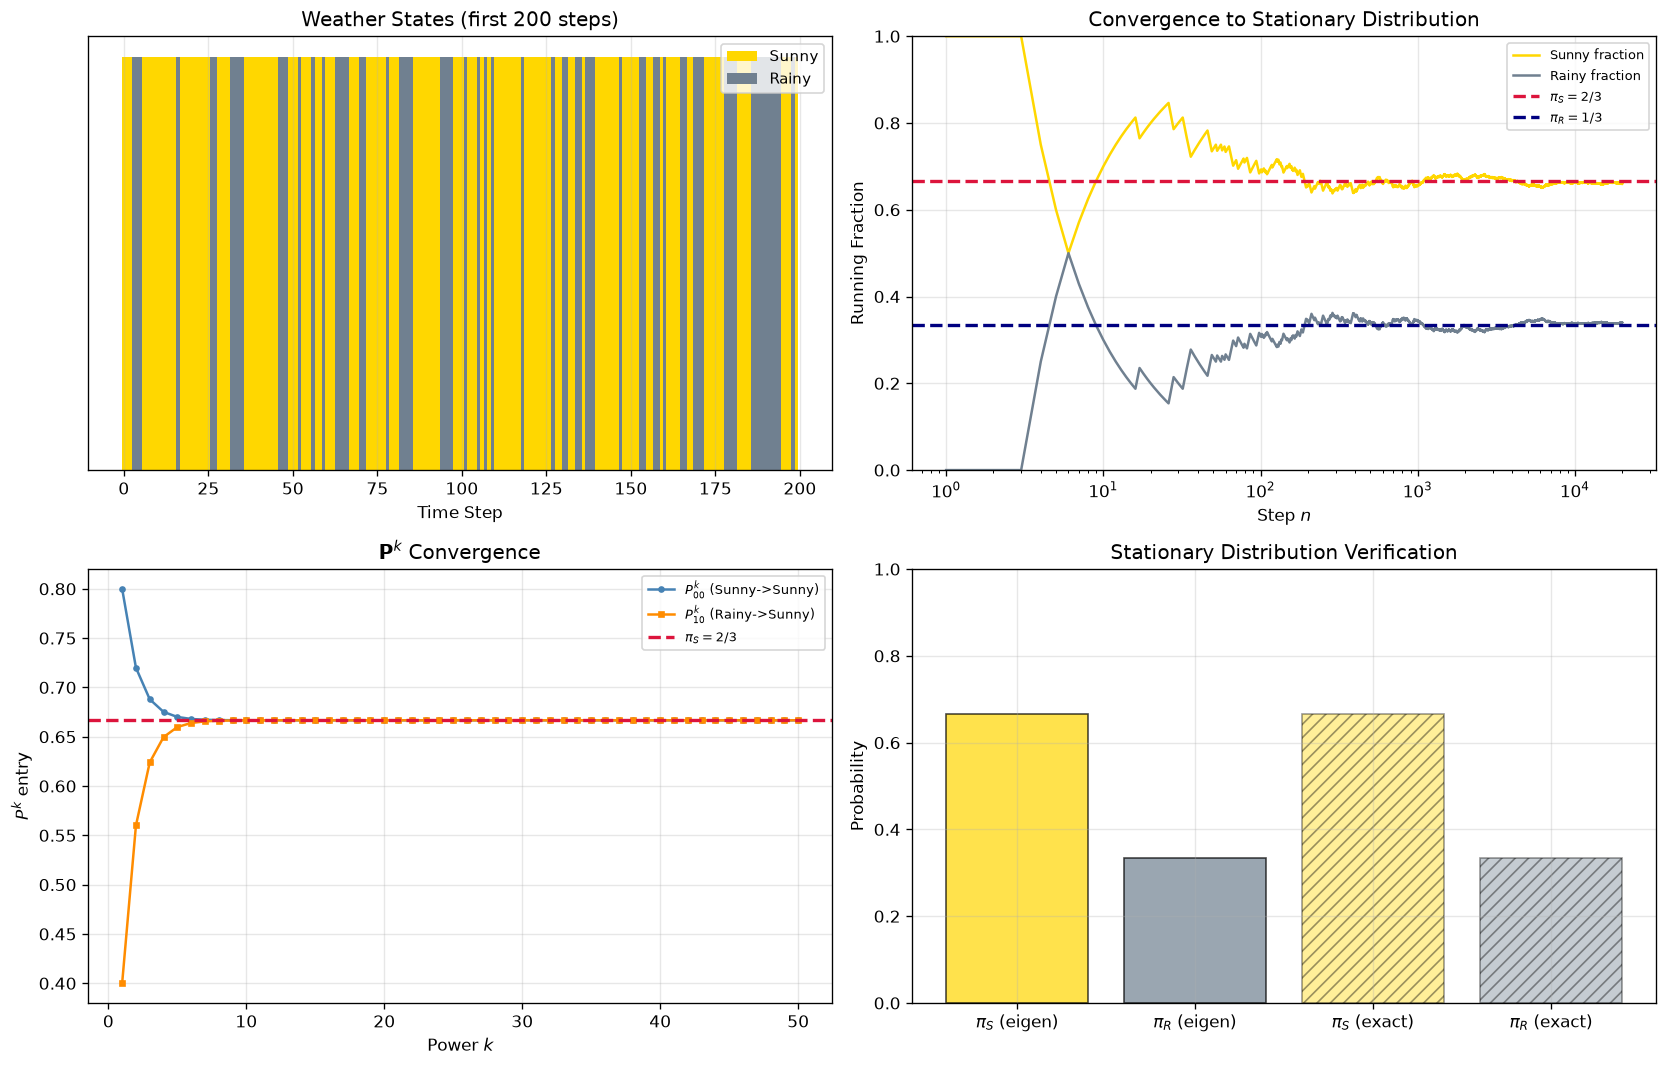

In [9]:
# Transition matrix from theory.md
P = np.array([[0.8, 0.2],
              [0.4, 0.6]])
states = ['Sunny', 'Rainy']

# --- Part 1: Simulate the chain ---
n_steps_mc = 20_000
state_seq = np.zeros(n_steps_mc, dtype=int)
state_seq[0] = 0  # Start sunny

for t in range(1, n_steps_mc):
    state_seq[t] = rng.choice([0, 1], p=P[state_seq[t-1]])

# Running fraction of sunny days
sunny_frac = np.cumsum(state_seq == 0) / np.arange(1, n_steps_mc + 1)
rainy_frac = np.cumsum(state_seq == 1) / np.arange(1, n_steps_mc + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Panel 1: State sequence (first 200 steps)
ax = axes[0, 0]
n_show = 200
colors_mc = ['gold' if s == 0 else 'slategray' for s in state_seq[:n_show]]
ax.bar(range(n_show), [1]*n_show, color=colors_mc, width=1.0, edgecolor='none')
ax.set_xlabel('Time Step')
ax.set_yticks([])
ax.set_title(f'Weather States (first {n_show} steps)')
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor='gold', label='Sunny'),
                  Patch(facecolor='slategray', label='Rainy')]
ax.legend(handles=legend_patches, fontsize=9)

# Panel 2: Convergence of running fractions
ax = axes[0, 1]
ax.semilogx(range(1, n_steps_mc + 1), sunny_frac, color='gold', linewidth=1.5,
            label='Sunny fraction')
ax.semilogx(range(1, n_steps_mc + 1), rainy_frac, color='slategray', linewidth=1.5,
            label='Rainy fraction')
ax.axhline(y=2/3, color='crimson', linestyle='--', linewidth=2, label='$\\pi_S = 2/3$')
ax.axhline(y=1/3, color='navy', linestyle='--', linewidth=2, label='$\\pi_R = 1/3$')
ax.set_xlabel('Step $n$')
ax.set_ylabel('Running Fraction')
ax.set_title('Convergence to Stationary Distribution')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

# --- Part 2: Powers of P ---
ax = axes[1, 0]
Pk = np.eye(2)
k_range = range(1, 51)
entries_00 = []
entries_10 = []
for k in k_range:
    Pk = Pk @ P
    entries_00.append(Pk[0, 0])
    entries_10.append(Pk[1, 0])

ax.plot(list(k_range), entries_00, 'o-', markersize=3, color='steelblue',
        label='$P^k_{00}$ (Sunny->Sunny)')
ax.plot(list(k_range), entries_10, 's-', markersize=3, color='darkorange',
        label='$P^k_{10}$ (Rainy->Sunny)')
ax.axhline(y=2/3, color='crimson', linestyle='--', linewidth=2, label='$\\pi_S = 2/3$')
ax.set_xlabel('Power $k$')
ax.set_ylabel('$P^k$ entry')
ax.set_title('$\\mathbf{P}^k$ Convergence')
ax.legend(fontsize=8)

# --- Part 3: Eigenvalue verification ---
ax = axes[1, 1]

# Left eigenvectors: solve pi @ P = pi, i.e. P^T @ pi^T = pi^T
eigenvalues, eigenvectors = np.linalg.eig(P.T)

# Find eigenvector for eigenvalue = 1
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi_eigen = eigenvectors[:, idx].real
pi_eigen = pi_eigen / pi_eigen.sum()  # Normalize

print('Markov Chain -- Eigenvalue Verification')
print('=' * 45)
print(f'Transition matrix P:')
print(P)
print(f'\nEigenvalues of P: {eigenvalues}')
print(f'Stationary distribution (from eigenvector): {pi_eigen}')
print(f'Stationary distribution (exact):            [2/3, 1/3] = [{2/3:.6f}, {1/3:.6f}]')
print(f'Verification: pi @ P = {pi_eigen @ P}')
print(f'Match: {np.allclose(pi_eigen @ P, pi_eigen)}')

# Visualize the eigenvalue verification
ax.bar(['$\\pi_S$ (eigen)', '$\\pi_R$ (eigen)'],
       pi_eigen, color=['gold', 'slategray'], edgecolor='black', linewidth=1, alpha=0.7,
       label='Eigenvector')
ax.bar(['$\\pi_S$ (exact)', '$\\pi_R$ (exact)'],
       [2/3, 1/3], color=['gold', 'slategray'], edgecolor='black', linewidth=1, alpha=0.4,
       hatch='///', label='Exact')
ax.set_ylabel('Probability')
ax.set_title('Stationary Distribution Verification')
ax.set_ylim(0, 1)

# Simulation estimate
pi_sim = np.array([np.mean(state_seq == 0), np.mean(state_seq == 1)])
print(f'Stationary distribution (simulation):       {pi_sim}')

plt.tight_layout()
plt.savefig('markov_chain.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Maximum Likelihood Estimation — From Scratch

We derive and implement MLE estimators for the Normal and Exponential distributions.

### Normal Distribution MLE

Given i.i.d. samples $x_1, \ldots, x_n \sim \mathcal{N}(\mu, \sigma^2)$:

$$\mathcal{L}(\mu, \sigma^2) = \prod_{i=1}^n \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

$$\ell(\mu, \sigma^2) = -\frac{n}{2}\ln(2\pi) - n\ln\sigma - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2$$

Setting $\frac{\partial \ell}{\partial \mu} = 0$ and $\frac{\partial \ell}{\partial \sigma^2} = 0$:

$$\boxed{\hat{\mu}_{\text{MLE}} = \bar{x} = \frac{1}{n}\sum_{i=1}^n x_i, \qquad \hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2}$$

### Exponential Distribution MLE

Given i.i.d. samples $x_1, \ldots, x_n \sim \text{Exp}(\lambda)$:

$$\ell(\lambda) = n\ln\lambda - \lambda \sum_{i=1}^n x_i$$

Setting $\frac{d\ell}{d\lambda} = 0$:

$$\boxed{\hat{\lambda}_{\text{MLE}} = \frac{1}{\bar{x}} = \frac{n}{\sum_{i=1}^n x_i}}$$

Maximum Likelihood Estimation (from scratch)

Normal Distribution:
  True:      mu = 5.00, sigma^2 = 4.00
  MLE:       mu = 5.1515, sigma^2 = 3.3787
  sigma_hat = 1.8381

Exponential Distribution:
  True:      lambda = 1.50
  MLE:       lambda = 1.4181
  1/lambda_hat = 0.7052 (true mean = 0.6667)


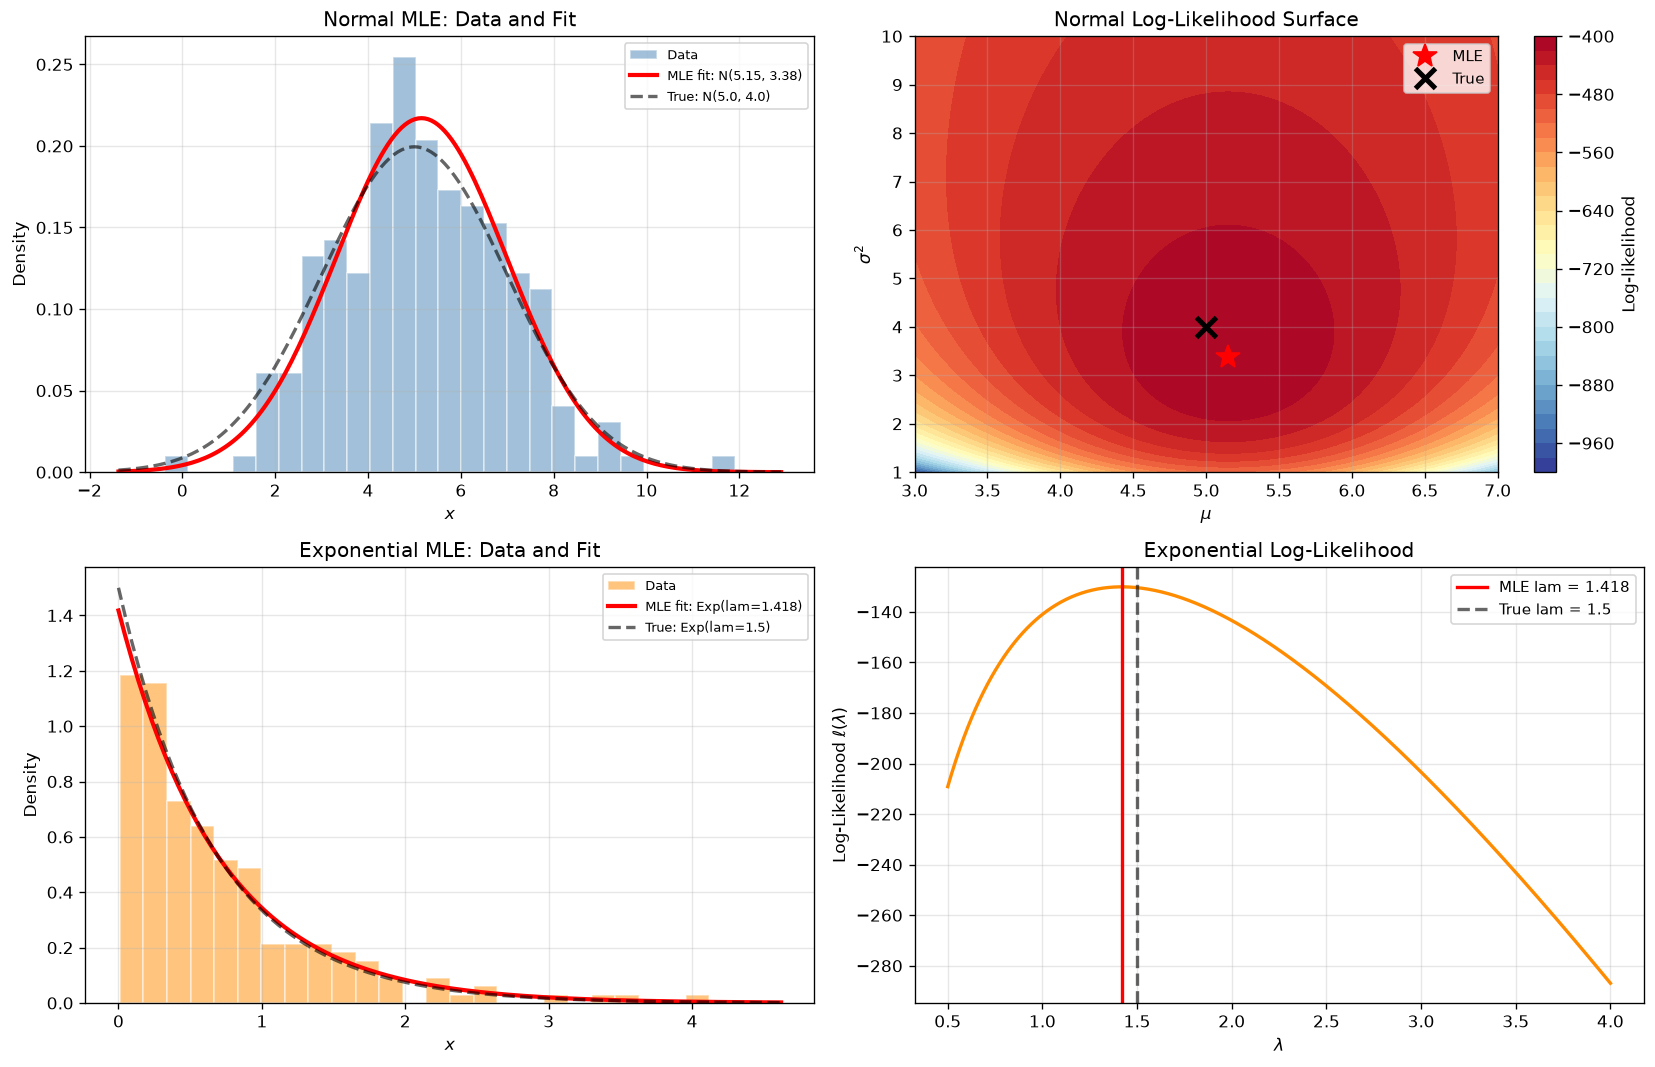

In [10]:
# --- MLE from scratch ---

def mle_normal(data):
    # MLE for Normal distribution parameters.
    # mu_hat = mean(x), sigma2_hat = mean((x - mu_hat)^2) [uses 1/n, not 1/(n-1)]
    mu_hat = np.mean(data)
    sigma2_hat = np.mean((data - mu_hat)**2)
    return mu_hat, sigma2_hat

def mle_exponential(data):
    # MLE for Exponential rate parameter: lambda_hat = 1/mean(x)
    lambda_hat = 1.0 / np.mean(data)
    return lambda_hat

def normal_log_likelihood(data, mu, sigma2):
    # Log-likelihood for Normal(mu, sigma2)
    n = len(data)
    return -n/2 * np.log(2*np.pi) - n/2 * np.log(sigma2) - np.sum((data - mu)**2) / (2*sigma2)

def exponential_log_likelihood(data, lam):
    # Log-likelihood for Exponential(lambda)
    n = len(data)
    return n * np.log(lam) - lam * np.sum(data)

# --- Generate data ---
true_mu, true_sigma = 5.0, 2.0
true_lambda = 1.5

data_normal = rng.normal(true_mu, true_sigma, size=200)
data_exp = rng.exponential(1/true_lambda, size=200)

# --- Compute MLE estimates ---
mu_hat, sigma2_hat = mle_normal(data_normal)
lambda_hat = mle_exponential(data_exp)

print('Maximum Likelihood Estimation (from scratch)')
print('=' * 50)
print(f'\nNormal Distribution:')
print(f'  True:      mu = {true_mu:.2f}, sigma^2 = {true_sigma**2:.2f}')
print(f'  MLE:       mu = {mu_hat:.4f}, sigma^2 = {sigma2_hat:.4f}')
print(f'  sigma_hat = {np.sqrt(sigma2_hat):.4f}')
print(f'\nExponential Distribution:')
print(f'  True:      lambda = {true_lambda:.2f}')
print(f'  MLE:       lambda = {lambda_hat:.4f}')
print(f'  1/lambda_hat = {1/lambda_hat:.4f} (true mean = {1/true_lambda:.4f})')

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Panel 1: Normal data histogram + MLE fit
ax = axes[0, 0]
ax.hist(data_normal, bins=25, density=True, alpha=0.5, color='steelblue',
        edgecolor='white', label='Data')
x_range = np.linspace(data_normal.min() - 1, data_normal.max() + 1, 200)
ax.plot(x_range, stats.norm.pdf(x_range, mu_hat, np.sqrt(sigma2_hat)),
        'r-', linewidth=2.5, label=f'MLE fit: N({mu_hat:.2f}, {sigma2_hat:.2f})')
ax.plot(x_range, stats.norm.pdf(x_range, true_mu, true_sigma),
        'k--', linewidth=2, alpha=0.6, label=f'True: N({true_mu}, {true_sigma**2})')
ax.set_title('Normal MLE: Data and Fit')
ax.set_xlabel('$x$')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Panel 2: Normal log-likelihood surface
ax = axes[0, 1]
mu_grid = np.linspace(true_mu - 2, true_mu + 2, 100)
sigma2_grid = np.linspace(1, 10, 100)
MU, S2 = np.meshgrid(mu_grid, sigma2_grid)
LL = np.array([[normal_log_likelihood(data_normal, m, s)
                for m, s in zip(mu_row, s2_row)]
               for mu_row, s2_row in zip(MU, S2)])
contour = ax.contourf(MU, S2, LL, levels=30, cmap='RdYlBu_r')
ax.plot(mu_hat, sigma2_hat, 'r*', markersize=15, label='MLE')
ax.plot(true_mu, true_sigma**2, 'kx', markersize=12, markeredgewidth=3, label='True')
plt.colorbar(contour, ax=ax, label='Log-likelihood')
ax.set_xlabel('$\\mu$')
ax.set_ylabel('$\\sigma^2$')
ax.set_title('Normal Log-Likelihood Surface')
ax.legend(fontsize=9)

# Panel 3: Exponential data histogram + MLE fit
ax = axes[1, 0]
ax.hist(data_exp, bins=25, density=True, alpha=0.5, color='darkorange',
        edgecolor='white', label='Data')
x_range_exp = np.linspace(0, data_exp.max() + 0.5, 200)
ax.plot(x_range_exp, stats.expon.pdf(x_range_exp, scale=1/lambda_hat),
        'r-', linewidth=2.5, label=f'MLE fit: Exp(lam={lambda_hat:.3f})')
ax.plot(x_range_exp, stats.expon.pdf(x_range_exp, scale=1/true_lambda),
        'k--', linewidth=2, alpha=0.6, label=f'True: Exp(lam={true_lambda})')
ax.set_title('Exponential MLE: Data and Fit')
ax.set_xlabel('$x$')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Panel 4: Exponential log-likelihood curve
ax = axes[1, 1]
lambda_grid = np.linspace(0.5, 4.0, 500)
ll_exp = [exponential_log_likelihood(data_exp, l) for l in lambda_grid]
ax.plot(lambda_grid, ll_exp, color='darkorange', linewidth=2)
ax.axvline(x=lambda_hat, color='red', linestyle='-', linewidth=2,
           label=f'MLE lam = {lambda_hat:.3f}')
ax.axvline(x=true_lambda, color='black', linestyle='--', linewidth=2, alpha=0.6,
           label=f'True lam = {true_lambda}')
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('Log-Likelihood $\\ell(\\lambda)$')
ax.set_title('Exponential Log-Likelihood')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('mle_estimation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Memoryless Property of the Exponential Distribution

From theory.md Section 4.2 (Exponential Distribution):

$$P(X > s + t \mid X > s) = P(X > t)$$

**Proof:**

$$P(X > s + t \mid X > s) = \frac{P(X > s + t)}{P(X > s)} = \frac{e^{-\lambda(s+t)}}{e^{-\lambda s}} = e^{-\lambda t} = P(X > t)$$

We verify this empirically: generate exponential samples, condition on $X > s$,
and check that the residual $X - s$ follows the same exponential distribution.

Memoryless Property Verification
Exponential(lambda=0.5), n=500,000

  s=1.0, t=2.0: P(X>3.0|X>1.0) = 0.3659, P(X>2.0) = 0.3679, ratio = 0.9945
  s=2.0, t=2.0: P(X>4.0|X>2.0) = 0.3655, P(X>2.0) = 0.3679, ratio = 0.9935


  s=3.0, t=2.0: P(X>5.0|X>3.0) = 0.3677, P(X>2.0) = 0.3679, ratio = 0.9996
  s=5.0, t=2.0: P(X>7.0|X>5.0) = 0.3653, P(X>2.0) = 0.3679, ratio = 0.9929


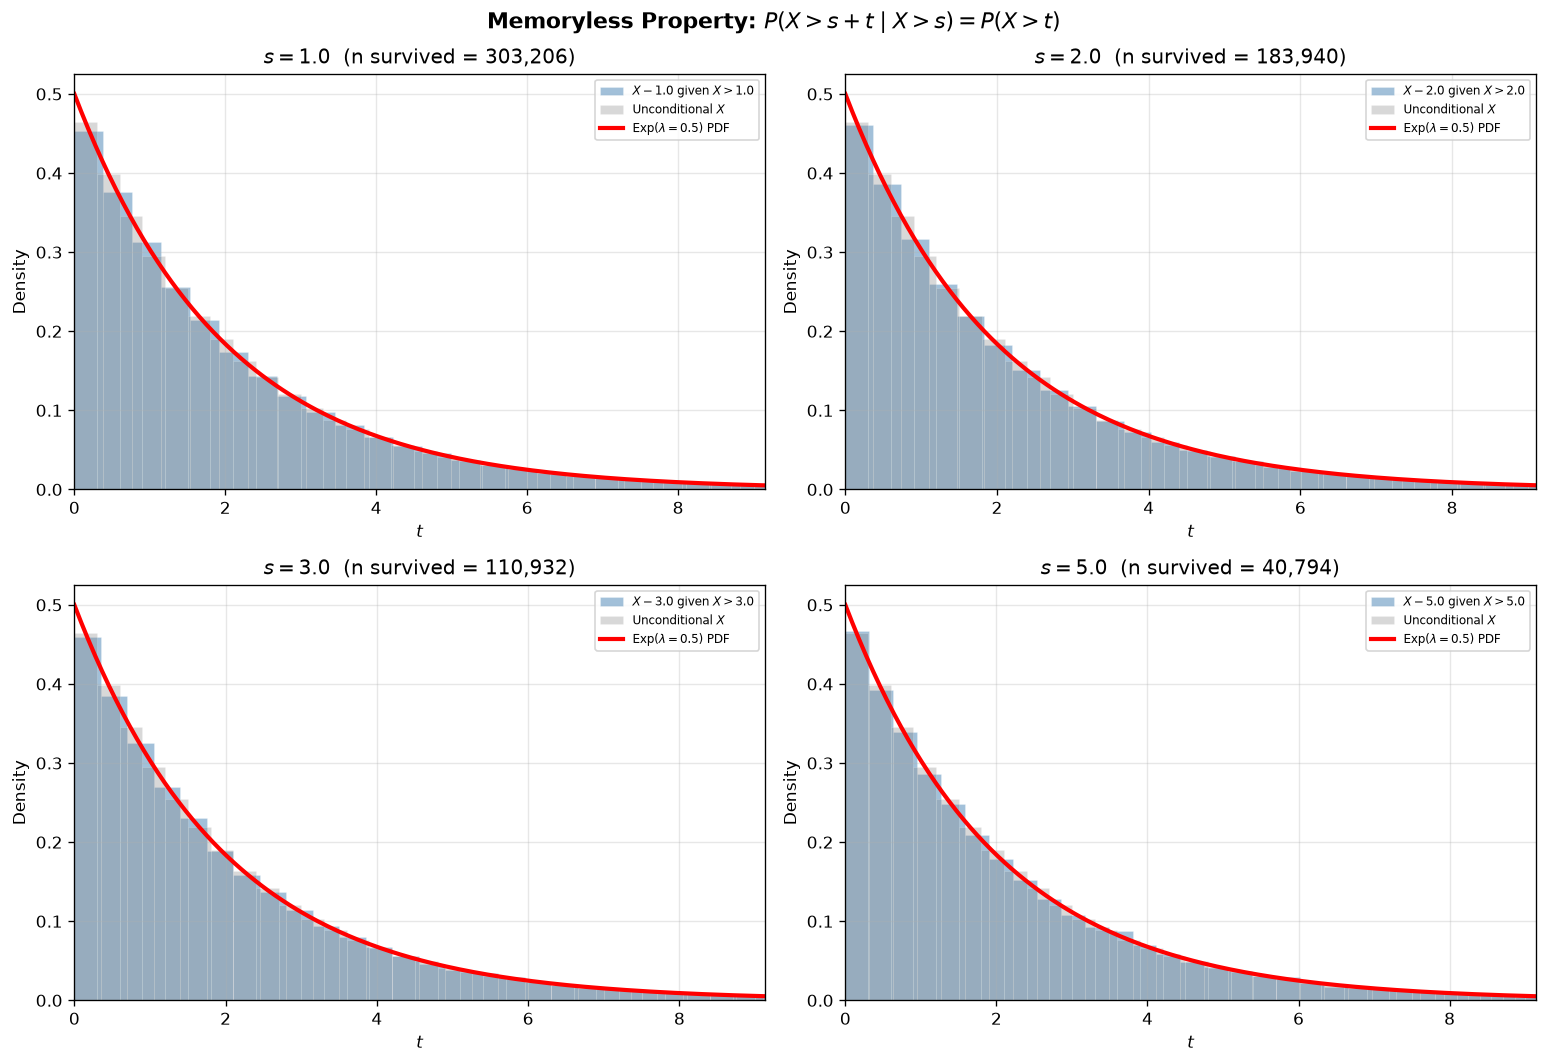


All ratios are close to 1.0, confirming the memoryless property.
The residual (X - s | X > s) follows the same Exp(lambda) distribution as X itself.


In [11]:
lam_mem = 0.5
s_values = [1.0, 2.0, 3.0, 5.0]
n_samples_mem = 500_000

samples = rng.exponential(scale=1/lam_mem, size=n_samples_mem)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Memoryless Property: $P(X > s+t \\mid X > s) = P(X > t)$',
             fontsize=13, fontweight='bold')

print('Memoryless Property Verification')
print('=' * 55)
print(f'Exponential(lambda={lam_mem}), n={n_samples_mem:,}')
print()

for idx, s in enumerate(s_values):
    ax = axes[idx // 2, idx % 2]

    # Condition on X > s and compute residual
    survived = samples[samples > s]
    residual = survived - s

    # Plot residual distribution vs unconditional Exp(lambda)
    ax.hist(residual, bins=60, density=True, alpha=0.5, color='steelblue',
            edgecolor='white', linewidth=0.3, label=f'$X - {s}$ given $X > {s}$')
    ax.hist(samples, bins=80, density=True, alpha=0.3, color='gray',
            edgecolor='white', linewidth=0.3, label='Unconditional $X$')

    t_range = np.linspace(0, np.percentile(residual, 99), 200)
    ax.plot(t_range, lam_mem * np.exp(-lam_mem * t_range), 'r-', linewidth=2.5,
            label=f'Exp($\\lambda={lam_mem}$) PDF')

    ax.set_xlabel('$t$')
    ax.set_ylabel('Density')
    ax.set_title(f'$s = {s}$  (n survived = {len(survived):,})')
    ax.legend(fontsize=7)
    ax.set_xlim(0, np.percentile(residual, 99))

    # Numerical verification: P(X > s+t | X > s) vs P(X > t)
    t_test = 2.0
    p_conditional = np.mean(residual > t_test)
    p_marginal = np.mean(samples > t_test)

    print(f'  s={s:.1f}, t={t_test:.1f}: P(X>{s+t_test:.1f}|X>{s:.1f}) = {p_conditional:.4f}, '
          f'P(X>{t_test:.1f}) = {p_marginal:.4f}, '
          f'ratio = {p_conditional/p_marginal:.4f}')

plt.tight_layout()
plt.savefig('memoryless_property.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAll ratios are close to 1.0, confirming the memoryless property.')
print('The residual (X - s | X > s) follows the same Exp(lambda) distribution as X itself.')

---
## Summary

This notebook implemented computational demonstrations for all major topics in the
probability and statistics theory module:

| Section | Topic | Key Result Verified |
|---|---|---|
| 1 | Distribution Gallery | PMF/PDF shapes, $E[X]$, $\operatorname{Var}(X)$ for all 6 distributions |
| 2 | Bayes' Theorem | Base rate fallacy: 95% sensitive test → only 8.8% PPV at 1% prevalence |
| 3 | Conditional Probability | Simulation matches exact $P(A|B) = P(A \cap B)/P(B)$ |
| 4 | Monte Carlo $\pi$ | $\hat{\pi}_n \to \pi$ with $O(1/\sqrt{n})$ error (CLT) |
| 5 | Law of Large Numbers | $\bar{X}_n \to E[X] = 3.5$ for die rolls |
| 6 | Central Limit Theorem | Non-normal distributions → $\mathcal{N}(0,1)$ as $n$ increases |
| 7 | Random Walks | RMS displacement scales as $\sqrt{n}$ (1D and 2D) |
| 8 | Markov Chain | Weather model converges to $\boldsymbol{\pi} = (2/3, 1/3)$; eigenvalue verification |
| 9 | MLE | Derived and implemented estimators for Normal and Exponential |
| 10 | Memoryless Property | $(X - s \mid X > s) \sim \text{Exp}(\lambda)$ verified empirically |

**Connections to mathematical modeling:**
- Monte Carlo methods (Section 4) underpin simulation-based modeling throughout the repository
- LLN and CLT (Sections 5-6) justify averaging and normal approximations in statistical models
- Markov chains (Section 8) are the foundation for stochastic population models
- MLE (Section 9) is the standard method for fitting models to data
- Random walks (Section 7) model diffusion, Brownian motion, and stochastic processes